# 11 · Localiser avec le modèle dual

**Question.** Sur les mêmes alarmes, la carte placée avec les débits virtuels envoie-t-elle l'équipe moins
souvent au mauvais endroit que la carte de pression ?

**Pourquoi.** L'étape 07 a montré que la plupart des fausses alarmes viennent de la **localisation** : une
fuite a bien grandi, mais l'alarme part à plus de 300 m. L'étape 10 a montré que le débit virtuel est plus
**localisé** que la pression : le capteur le plus proche d'une casse en porte une grande part. On garde donc
tout le reste de la chaîne et on change seulement ce que la carte compare.

Le code de cette étape : `etapes/e11_localiser_dual.py`. Il reprend la partie 5 du carnet e du dossier
04, avec trois changements : le dictionnaire dual a la même coupure que l'année (étape 10), l'écart toléré
`σ` du dual est réglé comme celui de la pression (le dossier 04 gardait une valeur par défaut, jamais
réglée), et les alarmes sont celles de la chaîne de l'étape 08.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from etapes import reglages as G, resultats as Res
from etapes.affichage import afficher
from IPython.display import display

plt.rcParams.update({"figure.figsize": (10, 3.4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.precision", 2)
pd.set_option("display.max_colwidth", None)
from etapes import e00_donnees as D, e01_residu as R1, e02_cusum as C, e03_bilan as B3, e05_signatures as Sg
from etapes import e06_chaine as Ch, e07_fausses as F, e08_regrouper as Rg, e09_combiner as E9, e10_dual as Du, e11_localiser_dual as L11

## Réglages utilisés

In [2]:
afficher(G.tableau(["DEBIT_DICO", "SIGMA_CM", "SIGMA_RELATIF", "SIGMA_DUAL_04", "AMPLITUDE_MAX", "PART_NETTE",
                    "K", "SEUIL", "CHOIX_CUSUM", "CHOIX_DEBIT", "ABSTENIR_SI_PLATE", "CHOIX_FUSIONNER_J", "CHOIX_CONFIRMER",
                    "RAYON", "TIRAGES", "GRAINE"]))

,valeur,unité,ce qu'il contrôle,origine
DEBIT_DICO,10.00,m³/h,le débit de la fuite simulée sur chaque conduite (le dictionnaire des signatures),choix
SIGMA_CM,0.60,cm,l'écart toléré par capteur entre l'observation et la signature,bruit sur 24 h (étape 01)
SIGMA_RELATIF,0.06,,"… ou cette part de la taille de l'observation, si c'est plus",choix
SIGMA_DUAL_04,1.00,m³/h,l'écart toléré par capteur pour la carte du dual dans le dossier 04 (jamais réglé),dossier 04 (valeur par défaut)
AMPLITUDE_MAX,5.00,,amplitude maximale de la signature (5 × 10 = 50 m³/h),choix
PART_NETTE,0.50,,"pour régler SIGMA_RELATIF, on ne garde que les fuites dont l'écart restant fait moins de cette part de la baisse observée",choix
K,2.00,cm,baisse tolérée chaque heure avant que le CUSUM cumule,réglé sur 2018
SEUIL,24.00,cm·h,cumul qui déclenche l'alarme,réglé sur 2018
CHOIX_CUSUM,3/18,K cm / SEUIL cm·h,le réglage du CUSUM de pression utilisé à partir de l'étape 06,"choisi en euros à l'étape 06, sur 2018, dans l'échantillon"
CHOIX_DEBIT,3/10,K m³/h / SEUIL m³/h·h,le réglage du CUSUM de débit utilisé à partir de l'étape 06,"choisi en euros à l'étape 06, sur 2018, dans l'échantillon"


In [3]:
import os
P = os.cpu_count()   # calcul long la première fois (gardé ensuite dans sorties/) : on prend tous les cœurs
res = R1.residu()
zones = R1.zones_des_capteurs(res.columns)
sig_p = R1.signal(res, zones)
bilan = B3.bilan_par_zone()
sig_d = B3.signal_debit(bilan)
fuites, debits = D.fuites_publiees()
wn = D.reseau()
dico = Sg.dictionnaire()
dist = Sg.distances(wn)
b = Ch.Bareme(wn, dist)
ch = Ch.chaine(res, sig_p, sig_d, dico, wn)          # la chaîne de l'étape 08 : réglages choisis + abstention
env = Ch.envois(ch)

qv = {True: Du.debits_virtuels(coupe=True, processus=P), False: Du.debits_virtuels(coupe=False, processus=P)}
dico_d = {True: Du.dictionnaire_dual(coupe=True, processus=P), False: Du.dictionnaire_dual(coupe=False, processus=P)}
pos = D.positions(wn)
xy = Sg.milieux(wn, dico.index)

## 1. La carte du dual

### La méthode

Exactement la carte de l'étape 05, avec d'autres ingrédients :

| | pression (étape 05) | dual (ici) |
|---|---|---|
| observation `o(c)` | baisse du résidu au capteur c (cm) | **hausse** de `q_v(c)` (m³/h) |
| intervalles | la veille / les 24 h suivantes (pression) ; les semaines (débit) | les mêmes |
| signature `S_p(c)` | baisse simulée pour 10 m³/h sur p (cm) | hausse simulée de `q_v(c)` pour 10 m³/h sur p (m³/h, étape 10, coupé) |
| amplitude | `a = S·o / S·S`, bornée à [0 ; 5] | la même |
| écart | `Σ (o − a·S)²` | le même |
| carte | `proba ∝ exp(−écart / 2σ²)`, `σ = max(σ₀, relatif × rms(o))` | la même, avec σ₀ et relatif du dual |

Les candidates sont les mêmes (conduites de la zone et de la frontière, visibles en pression), donc le
hasard du barème est le même : les z se comparent. Carte plate → on s'abstient, comme à l'étape 07.
Fonctions `observer_qv` et `relocaliser`.

## 2. Régler σ pour le dual

### La méthode

Comme à l'étape 05 : pour chaque fuite vue par le CUSUM de pression (réglage de référence), on prend
**la bonne** conduite et on mesure l'écart qui reste entre la hausse observée des `q_v` et sa signature :

- `σ₀` = l'écart médian par capteur (m³/h) ;
- `relatif` = la part médiane de l'écart dans la hausse observée, sur les fuites « nettes » (écart sous
  PART_NETTE = 50 % de la hausse).

C'est un réglage **sur les fuites qu'on note** (dans l'échantillon), comme `SIGMA_CM` et `SIGMA_RELATIF`
pour la pression. Le dossier 04 gardait σ = 1 m³/h et relatif = 0, sans réglage.

In [4]:
notes = C.detecter_annee(sig_p, fuites, debits)
ec = {c: L11.ecarts_par_fuite(qv[c], notes, dico_d[c]) for c in (True, False)}
display(afficher(ec[True], 2))
reg = {c: L11.regler_sigma(ec[c]) for c in (True, False)}
display(afficher(pd.DataFrame({"coupé": reg[True], "non coupé": reg[False]}, index=["σ₀ (m³/h)", "relatif"]), 3))
s_dual, r_dual = reg[True]

,écart (m³/h),hausse observée (m³/h),part de la baisse
fuite,,,
p232,0.17,0.79,0.22
p461,0.08,0.14,0.58
p673,0.91,4.02,0.23
p427,0.10,0.12,0.80
p628,0.16,0.31,0.50
p538,0.42,2.50,0.17
p866,1.42,2.57,0.55
p183,0.17,1.65,0.10
p654,0.09,0.09,0.98


,coupé,non coupé
σ₀ (m³/h),0.162,0.164
relatif,0.168,0.157


**Ce qu'on regarde.** Pour le dual coupé, σ₀ = **0,16 m³/h** et relatif = **0,17** ; presque pareil sans
coupure (0,16 et 0,16). Le dossier 04 gardait σ = 1 m³/h et relatif = 0. Les fuites lentes (p31, p257, p654,
p810) ont un écart presque égal à leur hausse : sur 24 h, le dual ne les voit pas plus que la pression. On verra
plus bas que σ ne change pas la conduite choisie.

## 3. Un exemple : la même alarme, deux cartes

alarme de pression du 20/03 01:00, zone AB, la fuite qui grandit : p461
pression → p124 à 713 m de la fuite (fausse) ; dual → p461 à 0 m (répétée)
9 alarmes sont dans ce cas : mal placées par la pression, à moins de 300 m d'une fuite en cours avec le dual


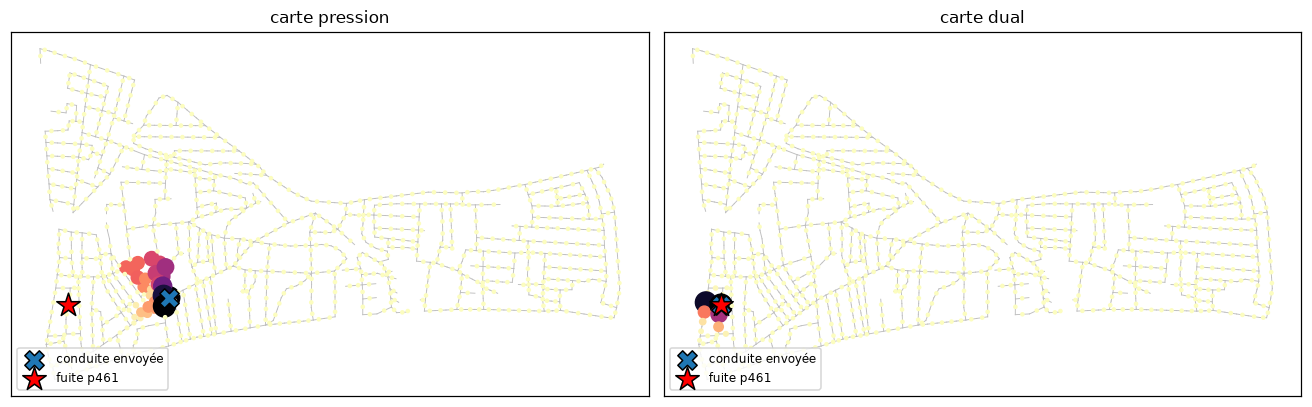

In [5]:
ch_d = L11.relocaliser(ch, qv[True], dico_d[True], s_dual, r_dual)
dp, dd = b.noter(Ch.envois(ch)), b.noter(Ch.envois(ch_d))
commun = dp.index.intersection(dd.index)
fp = F.anatomie(b, ch, fuites, debits)
gagnees = [i for i in commun if i in fp.index and fp.origine[i] != F.DETECTEUR and dd.type[i] in ("vraie", "répétée")]
i = gagnees[0]
r = ch.loc[i]
o_p = Sg.observer(res, (r.avant_debut, r.avant_fin), (r.apres_debut, r.apres_fin))
o_d = L11.observer_qv(qv[True], (r.avant_debut, r.avant_fin), (r.apres_debut, r.apres_fin))
cand = [p for p in r.candidates if p in dico_d[True].index]
cartes = {"pression": Sg.carte(o_p, dico.loc[r.candidates]), "dual": Sg.carte(o_d, dico_d[True].loc[cand], s_dual, r_dual)}
f_vraie = fp.loc[i, "fuite qui grandit le plus"]
print(f"alarme de {r.source} du {r.alarme:%d/%m %H:%M}, zone {r.zone}, la fuite qui grandit : {f_vraie}")
print(f"pression → {ch.conduite[i]} à {b.distance.at[ch.conduite[i], f_vraie]:.0f} m de la fuite ({dp.type[i]}) ; "
      f"dual → {ch_d.conduite[i]} à {b.distance.at[ch_d.conduite[i], f_vraie]:.0f} m ({dd.type[i]})")
print(f"{len(gagnees)} alarmes sont dans ce cas : mal placées par la pression, à moins de 300 m d'une fuite en cours avec le dual")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (nom, c) in zip(axes, cartes.items()):
    D.tracer_conduites(ax, wn)
    pr = c.proba.reindex(xy.index).fillna(0)
    sc = ax.scatter(xy.x, xy.y, c=pr, s=4 + 200 * pr / max(pr.max(), 1e-12), cmap="magma_r", zorder=3)
    ax.scatter(*xy.loc[c.proba.idxmax()], marker="X", s=160, c="tab:blue", edgecolors="k", zorder=5, label="conduite envoyée")
    if f_vraie:
        ax.scatter(*xy.loc[f_vraie], marker="*", s=260, c="red", edgecolors="k", zorder=6, label=f"fuite {f_vraie}")
    ax.set_title(f"carte {nom}")
    ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()

**Ce qu'on regarde.** Chaque point est une conduite candidate, d'autant plus gros et foncé qu'elle est
probable. La croix bleue est la conduite envoyée, l'étoile rouge la fuite qui a grandi entre les deux
intervalles (fichier publié, pour noter). La carte de pression envoie l'équipe sur p124, à 713 m de p461 qui continuait de
grandir : une fausse alarme. La carte du dual tombe sur p461 elle-même : une répétition, gratuite. 9 alarmes de
l'année sont dans ce cas.

## 4. Sur les alarmes de l'étape 08

### Comment lire les tableaux de règles

Chaque ligne est une façon de choisir les alarmes envoyées dans l'année. Les colonnes :

- **N** : le nombre d'alarmes envoyées. Une alarme, c'est une conduite et une date ;
- **trouvées** : combien des 14 fuites de 2018 ont reçu une alarme à moins de 300 m pendant qu'elles
  coulaient ;
- **fausses** : les alarmes à plus de 300 m de toute fuite en cours. Chacune coûte 500 € ;
- **répétées** : les alarmes près d'une fuite déjà trouvée. Elles ne rapportent rien et ne coûtent rien ;
- **euros** : le score du barème officiel (partie 2 de l'étape 06) ;
- **hasard ± σ** : le score moyen si l'on garde **les mêmes dates** mais qu'on envoie chaque alarme sur
  une conduite tirée au hasard parmi les candidates de sa zone (200 tirages), et l'écart-type de ces
  200 scores. C'est ce que vaut le calendrier des alarmes sans aucune localisation ;
- **z** : de combien d'écarts-types on bat le hasard, `z = (euros − hasard) / σ`. Au-dessus de 2 à 3, la
  localisation apporte vraiment quelque chose.

Deux colonnes de plus que d'habitude : **fausses : détecteur** (aucune fuite de la zone n'a grandi d'au
moins 0,5 m³/h entre les deux intervalles comparés) et **fausses : localisation** (une fuite a grandi, mais
l'alarme part à plus de 300 m), classées comme à l'étape 07.

In [6]:
def noter(ch_, nom):
    e = Ch.envois(ch_)
    return [E9.ligne_origines(b, ch_, e, fuites, debits, nom),
            E9.ligne_origines(b, ch_, Rg.regrouper(e, dist), fuites, debits, nom + " + regrouper")]

variantes = {
    "pression (étape 08)": ch,
    "dual du dossier 04 : non coupé, σ = 1, relatif = 0": L11.relocaliser(ch, qv[False], dico_d[False], G.SIGMA_DUAL_04, 0.0),
    "dual non coupé, σ réglé": L11.relocaliser(ch, qv[False], dico_d[False], *reg[False]),
    "dual mélangé : année coupée, signatures non coupées, σ réglé": L11.relocaliser(ch, qv[True], dico_d[False], *reg[True]),
    "dual coupé, σ = 1, relatif = 0": L11.relocaliser(ch, qv[True], dico_d[True], G.SIGMA_DUAL_04, 0.0),
    "dual coupé, σ réglé (corrigé)": ch_d,
}
lignes = [x for nom, c in variantes.items() for x in noter(c, nom)]
afficher(E9.tableau_origines(lignes), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,répétées,euros,hasard ± σ (€),z
règle,,,,,,,,,
pression (étape 08),63,13 / 14,24,7,17,26,142609,54 728 ± 20 075,4.4
pression (étape 08) + regrouper,20,12 / 14,8,3,5,0,139003,29 825 ± 21 258,5.1
"dual du dossier 04 : non coupé, σ = 1, relatif = 0",71,13 / 14,23,10,13,35,144343,55 128 ± 19 777,4.5
"dual du dossier 04 : non coupé, σ = 1, relatif = 0 + regrouper",18,12 / 14,5,2,3,1,147351,36 782 ± 20 211,5.5
"dual non coupé, σ réglé",71,13 / 14,23,10,13,35,144343,55 128 ± 19 777,4.5
"dual non coupé, σ réglé + regrouper",18,12 / 14,5,2,3,1,147351,36 782 ± 20 211,5.5
"dual mélangé : année coupée, signatures non coupées, σ réglé",71,13 / 14,22,10,12,36,144951,55 128 ± 19 777,4.5
"dual mélangé : année coupée, signatures non coupées, σ réglé + regrouper",18,12 / 14,5,2,3,1,147351,39 307 ± 20 277,5.3
"dual coupé, σ = 1, relatif = 0",71,13 / 14,22,10,12,36,145053,55 128 ± 19 777,4.5


**Ce qu'on regarde.** Avec le dual coupé, sur les mêmes alarmes : 13 fuites sur 14, 24 → **22 fausses**,
142 609 → **145 053 €** ; avec le regroupement, 8 → **5 fausses** et 139 003 → **147 351 €** (z +5,1 → +5,3).
Les fausses alarmes de **localisation** baissent (17 → 12), celles du **détecteur** montent (7 → 10) : la carte
du dual n'est presque jamais plate, donc il envoie aussi les 8 alarmes où la pression s'abstenait (3 fausses,
2 répétées, 3 vraies). La correction de l'étape 10 vaut 102 €, à nombres d'alarmes égaux (« mélangé » contre
« coupé ») ; couper plutôt que ne pas couper, une fausse alarme et 710 €. Les lignes « σ = 1 » et « σ réglé » sont identiques.

### Pourquoi σ ne change pas la conduite choisie

La carte vaut `proba ∝ exp(−écart / 2σ²)`, avec le même σ pour toutes les conduites d'une alarme. Plus
l'écart est petit, plus la probabilité est grande, **quel que soit σ** : la conduite la plus probable est
toujours celle de plus petit écart. σ ne change que l'**étalement** de la carte (une carte serrée ou
diffuse autour de cette conduite). La chaîne n'envoie que la conduite la plus probable : σ réglé ou non,
elle envoie les mêmes conduites, ce que confirment les lignes identiques du tableau. Le réglage de σ
comptera quand on se servira de la carte entière (étapes suivantes).

### Alarme par alarme

Le type au barème de chaque alarme avec la carte de pression (lignes) et avec la carte du dual corrigée
(colonnes), sans regroupement. « abstention » : la carte est plate, rien n'est envoyé.

In [7]:
afficher(L11.changements(b, ch, ch_d), 0)

dual,fausse,répétée,vraie,total
pression,,,,
abstention,3,2,3,8
fausse,14,10,0,24
répétée,4,22,0,26
vraie,1,2,10,13
total,22,36,13,71


## 5. Les alarmes mal placées, avant et après

In [8]:
fd = F.anatomie(b, ch_d, fuites, debits)
display(afficher(pd.concat({"pression": F.tableau_origines(fp)["total"], "dual": F.tableau_origines(fd)["total"]}, axis=1).fillna(0), 0))
afficher(pd.DataFrame({"pression": F.resume_mal_placees(fp), "dual": F.resume_mal_placees(fd)}), 1)

,pression,dual
origine,,
détecteur : rien n'a bougé,7,10
localisation : fuite déjà trouvée,16,11
localisation : fuite nouvelle,1,1
total,24,22


,pression,dual
mal placées,17.0,12.0
distance médiane (m),433.5,488.5
dont distance infinie,1.0,0.0
distance médiane finie (m),432.7,488.5
pousse médiane (m³/h),3.2,1.5
sur une fuite déjà trouvée,16.0,11.0


**Ce qu'on regarde.** Les alarmes mal placées passent de **17 à 12**, et presque toutes tombent encore
sur une fuite déjà trouvée qui continue de grandir (16 → 11). Celles qui restent sont plus faibles (pousse
médiane 1,5 m³/h au lieu de 3,2) : le dual corrige d'abord les cas où la fuite grandit franchement. Le
détecteur, lui, en ajoute 3.

## 6. Le tableau final

Toutes les étapes de la chaîne, relues dans `sorties/resultats.csv` (aucun chiffre recopié à la main),
puis le dual sur les alarmes de l'étape 08, seul, avec la fusion et avec la confirmation de l'étape 09
(réglages choisis à l'étape 09).

In [9]:
x = {nom: noter(c, nom) for nom, c in (("dual coupé, σ réglé", ch_d),)}
e_fus = E9.fusionner(ch_d, G.CHOIX_FUSIONNER_J)
fus = [E9.ligne_origines(b, ch_d, e_fus, fuites, debits, f"dual + fusionner, W = {G.CHOIX_FUSIONNER_J:g} j"),
       E9.ligne_origines(b, ch_d, Rg.regrouper(e_fus, dist), fuites, debits,
                         f"dual + fusionner, W = {G.CHOIX_FUSIONNER_J:g} j + regrouper")]
pente = {z: R1.droite(R1.residu_contre_fuite(res, zones, debits, fuites, z))["pente_cm_par_m3h"] for z in ("AB", "C")}
bilan_h = bilan.resample("1h").mean()
res_h = res.resample("1h").mean()
res_zone_h = pd.DataFrame({z: res_h[[c for c in res_h.columns if zones[c] == z]].mean(axis=1) for z in ("AB", "C")})
quelles = {"pression": ("pression",), "débit": ("débit",), "les deux": ("pression", "débit")}[G.CHOIX_CONFIRMER[0]]
e_conf = E9.confirmer(ch_d, bilan_h, res_zone_h, pente, G.CHOIX_CONFIRMER[1], G.CHOIX_CONFIRMER[2], quelles)
fus += [E9.ligne_origines(b, ch_d, e_conf, fuites, debits, "dual + confirmer"),
        E9.ligne_origines(b, ch_d, Rg.regrouper(e_conf, dist), fuites, debits, "dual + confirmer + regrouper")]
display(afficher(E9.tableau_origines(fus), 1))
d_c = b.noter(Rg.regrouper(e_conf, dist))
qui = d_c[d_c.type == "vraie"].join(ch_d[["alarme", "source"]])[["fuite", "source", "alarme", "envoi", "conduite", "distance_m", "euros"]]
display(afficher(qui.set_index("fuite").sort_values("alarme"), 0))
for x_, v in zip(fus[2:], ["dual + confirmer", "dual + confirmer + regrouper"]):
    Res.ajouter("11", v, **Ch.colonnes_resultats(x_), fausses_detecteur=x_["fausses : détecteur"],
                fausses_localisation=x_["fausses : localisation"])
Res.ajouter("11", "dual + fusionner", **Ch.colonnes_resultats(fus[0]), fausses_detecteur=fus[0]["fausses : détecteur"],
            fausses_localisation=fus[0]["fausses : localisation"])
Res.ajouter("11", "dual + fusionner + regrouper", **Ch.colonnes_resultats(fus[1]), fausses_detecteur=fus[1]["fausses : détecteur"],
            fausses_localisation=fus[1]["fausses : localisation"])
for nom, (s, g) in x.items():
    Res.ajouter("11", "dual", **Ch.colonnes_resultats(s), fausses_detecteur=s["fausses : détecteur"],
                fausses_localisation=s["fausses : localisation"])
    Res.ajouter("11", "dual + regrouper", **Ch.colonnes_resultats(g), fausses_detecteur=g["fausses : détecteur"],
                fausses_localisation=g["fausses : localisation"])
for nom in ("dual du dossier 04 : non coupé, σ = 1, relatif = 0", "dual mélangé : année coupée, signatures non coupées, σ réglé"):
    s, g = noter(variantes[nom], nom)
    court = "dual 04" if nom.startswith("dual du dossier 04") else "dual melange"
    Res.ajouter("11", court, **Ch.colonnes_resultats(s))
    Res.ajouter("11", court + " + regrouper", **Ch.colonnes_resultats(g))
tout = Res.lire()
garde = [("06", "chaine reference 2/24 + 1.5/40"), ("06", "chaine choisie"), ("07", "chaine choisie avec abstention"),
         ("08", "chaine + abstention + regrouper"), ("09", "fusionner"), ("09", "fusionner + regrouper"),
         ("09", "confirmer"), ("09", "confirmer + regrouper"), ("09", "fondre"), ("09", "fondre + regrouper"),
         ("11", "dual 04"), ("11", "dual 04 + regrouper"), ("11", "dual"), ("11", "dual + regrouper"),
         ("11", "dual + fusionner"), ("11", "dual + fusionner + regrouper"),
         ("11", "dual + confirmer"), ("11", "dual + confirmer + regrouper")]
t = pd.concat([tout[(tout.etape == e) & (tout.version == v)] for e, v in garde])
t = t.assign(étape=t.etape + " · " + t.version).set_index("étape")
# l'étape 08 n'a pas classé ses fausses alarmes : l'étape 09 l'a fait sur les mêmes alarmes
d9 = tout[(tout.etape == "09") & (tout.version == "depart + regrouper")].iloc[0]
for c in ("fausses_detecteur", "fausses_localisation"):
    t.loc["08 · chaine + abstention + regrouper", c] = d9[c]
cols = ["alarmes", "trouvees", "fausses", "fausses_detecteur", "fausses_localisation", "euros", "hasard_euros", "hasard_sigma", "z"]
afficher(t[cols].rename(columns={"trouvees": "trouvées", "fausses_detecteur": "fausses : détecteur",
                                 "fausses_localisation": "fausses : localisation", "hasard_euros": "hasard (€)",
                                 "hasard_sigma": "σ (€)"}), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,répétées,euros,hasard ± σ (€),z
règle,,,,,,,,,
"dual + fusionner, W = 2 j",45,12 / 14,17,9,8,16,135754,50 633 ± 20 560,4.1
"dual + fusionner, W = 2 j + regrouper",15,11 / 14,3,1,2,1,136551,32 825 ± 23 902,4.3
dual + confirmer,44,13 / 14,8,3,5,23,148681,42 302 ± 22 568,4.7
dual + confirmer + regrouper,15,13 / 14,2,2,0,0,151681,22 767 ± 22 537,5.7


,source,alarme,envoi,conduite,distance_m,euros
fuite,,,,,,
p257,débit,2018-01-14 21:00,2018-01-21 21:00,p257,0,44 403
p232,pression,2018-02-01 23:00,2018-02-02 23:00,p232,0,3 619
p461,débit,2018-02-16 23:00,2018-02-23 23:00,p461,0,14 116
p673,pression,2018-03-05 21:00,2018-03-06 21:00,p75,139,8 802
p427,débit,2018-04-27 12:00,2018-05-04 12:00,p427,0,23 217
p628,pression,2018-05-09 05:00,2018-05-10 05:00,p627,57,11 525
p538,pression,2018-05-18 17:00,2018-05-19 17:00,p121,39,8 374
p866,débit,2018-06-01 16:00,2018-06-08 16:00,p186,50,1 274
p31,débit,2018-07-09 15:00,2018-07-16 15:00,p252,264,5 696


,alarmes,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard (€),σ (€),z
étape,,,,,,,,,
06 · chaine reference 2/24 + 1.5/40,95,13,49,<NA>,<NA>,129102,53061,19756,3.8
06 · chaine choisie,71,13,31,<NA>,<NA>,139109,55128,19777,4.2
07 · chaine choisie avec abstention,63,13,24,7,17,142609,54728,20075,4.4
08 · chaine + abstention + regrouper,20,12,8,3,5,139003,29825,21258,5.1
09 · fusionner,42,12,16,7,9,135003,49429,20029,4.3
09 · fusionner + regrouper,19,12,6,3,3,140003,29463,19460,5.7
09 · confirmer,39,12,11,1,10,143379,44837,22948,4.3
09 · confirmer + regrouper,15,11,4,0,4,135273,24783,22128,5.0
09 · fondre,28,10,12,2,10,103405,37062,22768,2.9


## Réglé sur les années simulées

**Ce qu'on fait.** La version finale de ce carnet (carte du dual, confirmer, regrouper), avec **tous**
les réglages des étapes 06 et 09 choisis sur les 12 années simulées au lieu de 2018 : le couple de CUSUM
(carnet 06) et la confirmation (carnet 09). On la note sur 2018, à côté de la ligne finale actuelle.

### La méthode

- La chaîne réglée sur les années simulées : CUSUM `CHOIX_CUSUM_SIMULEES` et `CHOIX_DEBIT_SIMULEES`,
  abstention, carte du dual, confirmation `CHOIX_CONFIRMER_SIMULEES`, regroupement.
- **Ce qui reste réglé sur 2018** : le dictionnaire des signatures et le dictionnaire dual, le σ des
  cartes et celui du dual, la pente cm par m³/h, l'abstention. La ligne « réglé sur les simulées » n'est
  donc validée sur 2018 que pour les réglages des CUSUM et de la confirmation.
- Les deux versions sont aussi notées sur les 12 années simulées (sommes, comme aux carnets 06 et 09).

**Comment on additionne les années.** Les comptes (N, trouvées, fausses) et les euros des 12 années
s'additionnent. Le hasard de chaque année aussi ; comme les années sont indépendantes, l'écart-type du
hasard de la somme est la racine de la somme des carrés des σ, et z est celui de la somme. Les euros
d'une année seule ne se comparent pas d'une année à l'autre (elles n'ont pas les mêmes fuites) ; leur
somme, si : c'est l'argent d'une année moyenne, fois 12.

**La stabilité.** Le choix changerait-il avec d'autres années ? On refait chaque choix en retirant les
3 années d'un même réseau vrai (une variante), pour chacune des 4 variantes. Les grilles sont celles des
carnets 06 et 09 (gardées dans `sorties/`) : c'est immédiat. Pour la confirmation et la fusion, la grille
est celle de la chaîne réglée sur toutes les années.

**Temps de calcul.** La carte du dual pour les 12 années et les deux versions : environ une minute.

In [10]:
import os
from etapes import e12_annees_simulees as A12, e13_regler_sur_simulees as E
P = os.cpu_count()
ref12 = A12.reference_2018(P)          # ce que la chaîne garde de 2018 (dictionnaires, σ, pente)
a18 = E.annee_2018(ref12, P)
ans = E.annees_simulees(ref12, P)      # les 12 années de l'étape 12 (fabriquées la première fois)
choix_18 = (G.CHOIX_CUSUM, G.CHOIX_DEBIT)
choix_sim = (G.CHOIX_CUSUM_SIMULEES, G.CHOIX_DEBIT_SIMULEES)

versions11 = {"réglé sur 2018 (06, 09, 11)": (choix_18, G.CHOIX_CONFIRMER),
              "réglé sur les simulées": (choix_sim, G.CHOIX_CONFIRMER_SIMULEES)}
fin18, fin_sim, fin_classes = {}, {}, {}
for n, (c, k) in versions11.items():
    ch_d, e = E.finale(a18, ref12, *c, k)
    fin18[n] = E.ligne(a18, ch_d, e, f"{n} → noté sur 2018")
    par_an, tabs = [], []
    for a in ans.values():
        ch_d, e = E.finale(a, ref12, *c, k)
        par_an.append(E.ligne(a, ch_d, e, n))
        tabs.append(E.fuites_trouvees(a, e))
    fin_sim[n] = E.somme(par_an, f"{n} → noté sur les 12 années simulées")
    fin_classes[n] = tabs
print("la ligne « réglé sur 2018 » refait la ligne finale « dual + confirmer + regrouper » :",
      fin18["réglé sur 2018 (06, 09, 11)"]["euros"] == fus[3]["euros"])
afficher(E.tableau(list(fin18.values()) + list(fin_sim.values())), 1)

la ligne « réglé sur 2018 » refait la ligne finale « dual + confirmer + regrouper » : True


,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
"réglé sur 2018 (06, 09, 11) → noté sur 2018",15,13 / 14,2,2,0,151681,22 767 ± 22 537,5.7
réglé sur les simulées → noté sur 2018,15,13 / 14,2,2,0,151806,22 784 ± 22 544,5.7
"réglé sur 2018 (06, 09, 11) → noté sur les 12 années simulées",181,75 / 181,103,57,46,1574392,438 429 ± 138 796,8.2
réglé sur les simulées → noté sur les 12 années simulées,182,76 / 181,103,57,46,1579631,422 338 ± 136 209,8.5


**Ce qu'on regarde.** Les deux premières lignes sont notées sur 2018, les deux dernières sur les 12 années
simulées (sommes). **Noté sur 2018, la chaîne réglée sur les années simulées fait 151 806 € contre
151 681 €** : 125 € de plus, 0,006 σ du hasard. Elle envoie les mêmes 15 alarmes, trouve les mêmes 13 fuites,
avec les mêmes 2 fausses alarmes. Seul le seuil du CUSUM de pression a changé, et après la confirmation et le
regroupement il ne change presque plus rien. Sur les 12 années simulées aussi : 1 579 631 € contre 1 574 392 €
en tout (z 8,5 contre 8,2).

Par classe de fuite, sur les 12 années simulées :

In [11]:
afficher(E.par_classe(fin_classes), 2)

**Ce qu'on regarde.** Les deux versions trouvent les mêmes parts de fuites, classe par classe, à une fuite près.
La version finale trouve **une casse sur deux, même au-dessus de 20 m³/h**, et 30 à 44 % des fuites qui
grandissent : c'est le regroupement et la confirmation qui les perdent (carnet 09, tableau ci-dessus).

### La stabilité

In [12]:
g06 = E.en_cache("06", lambda: E.grilles(ans, lambda a: E.grille_06(a, ref12)))
gc = E.en_cache("09_confirmer", lambda: E.grilles(ans, lambda a: E.grille_confirmer(a, E.chaine(a, ref12, *choix_sim), ref12)))
gf = E.en_cache("09_fusionner", lambda: E.grilles(ans, lambda a: E.grille_fusionner(a, E.chaine(a, ref12, *choix_sim))))
afficher(pd.DataFrame({
    "CUSUM pression + bilan (06)": E.sans_une_variante(g06).map(lambda x: f"{x[0]} + {x[1]}"),
    "confirmer (09)": E.sans_une_variante(gc).map(lambda x: f"{x[0]}, X = {float(x[1]):g}, H = {int(x[2])}"),
    "fusionner (09)": E.sans_une_variante(gf).map(lambda w: f"W = {float(w):g} j")}), 0)

,CUSUM pression + bilan (06),confirmer (09),fusionner (09)
toutes les années,3/12 + 3/10,"pression, X = 4, H = 24",W = 0.5 j
sans la variante v0,3/18 + 3/10,"pression, X = 4, H = 24",W = 0.5 j
sans la variante v1,3/12 + 1.5/80,"pression, X = 4, H = 24",W = 0.5 j
sans la variante v2,3/12 + 3/10,"les deux, X = 2, H = 48",W = 0.5 j
sans la variante v3,3/12 + 3/10,"pression, X = 4, H = 24",W = 0.5 j


**Ce qu'on regarde.** **Le choix est stable, sauf à la marge.** En retirant une des quatre variantes, la fusion
garde W = 12 h quatre fois sur quatre. Le couple de CUSUM et la confirmation gardent leur choix trois fois sur
quatre :
- sans la variante v0, le couple de CUSUM redevient celui de 2018 (3/18 + 3/10) ; sans la v1, le CUSUM du bilan
  passe à 1,5/80 ;
- sans la v2, la confirmation passe à « les deux, X = 2 m³/h, H = 48 h ».

À chaque fois, l'autre choix est à quelques milliers d'euros du premier, sur 2,5 millions : la grille est plate,
et le choix dépend des quelques fuites qui tombent près d'un seuil.

In [13]:
for v, x in {"final regle simulees note 2018": fin18["réglé sur les simulées"],
             "final regle 2018 note simulees": fin_sim["réglé sur 2018 (06, 09, 11)"],
             "final regle simulees note simulees": fin_sim["réglé sur les simulées"]}.items():
    r_ = Res.ajouter("11", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12 if v.endswith("simulees") else 1)
afficher(r_[r_.etape == "11"].set_index("version").drop(columns="etape").dropna(how="all", axis=1).tail(3), 1)

,alarmes,fausses,euros,trouvees,repetees,hasard_euros,hasard_sigma,z,fausses_detecteur,fausses_localisation,annees
version,,,,,,,,,,,
final regle simulees note 2018,15,2,151806,13,0,22784,22544,5.7,2,0,1
final regle 2018 note simulees,181,103,1574392,75,3,438429,138796,8.2,57,46,12
final regle simulees note simulees,182,103,1579631,76,3,422338,136209,8.5,57,46,12


### Ce qu'on retient ici

- **Toute la chaîne réglée sur les 12 années simulées donne, sur 2018, le même résultat que la chaîne
  réglée sur 2018** : 151 806 € contre 151 681 €, 15 alarmes, 13 fuites sur 14, 2 fausses, z = 5,7. L'écart
  (125 €) est 0,006 σ du hasard.
- **2018 est une année de validation pour ces lignes-là seulement**, et seulement pour le couple de CUSUM et la
  confirmation. Le dictionnaire, les σ des cartes, l'abstention, le regroupement, le σ du dual et la pente restent
  réglés sur 2018.
- Ce qui a été réglé sur 2018 n'était donc **pas sur-ajusté** : les années simulées choisissent les mêmes
  réglages, ou des voisins qui rapportent autant. Les fausses alarmes de plus vues à l'étape 12 ne viennent pas
  de ces réglages-là.
- **Le prochain levier, vu sur les années simulées** : le regroupement leur coûte près d'un tiers des euros, et la
  version finale y trouve une grosse casse sur deux.

### Tous les réglages : la carte, la combinaison et le regroupement ensemble

**Ce qu'on fait.** Sur 2018, la version finale (carte du dual, confirmer, regrouper à 300 m) a été choisie
en comparant des lignes de 2018. Ici, on essaie toutes les combinaisons de la carte (pression ou dual), de
la façon de combiner (rien, confirmer, fusionner, fondre, chacune avec son réglage du carnet 09) et du
regroupement (aucun, ou un rayon), sur la chaîne réglée sur les années simulées aux étapes d'avant. On
vérifie aussi que le σ du dual ne change aucune alarme, comme σ au carnet 05.

### La méthode

- **Dans l'ordre de la chaîne.** Les réglages sont choisis dans le même ordre que sur 2018 : CUSUM
  (étapes 02, 03 et 06), lecture d'une alarme (05), s'abstenir (07), regrouper (08), combiner (09),
  carte du dual (11). Chaque choix sur les années simulées part de la chaîne **déjà réglée sur elles**
  aux étapes d'avant ; chaque choix sur 2018 part de la chaîne réglée sur 2018.
- **L'objectif** est le même qu'en phase 2 : la somme des euros des 12 années simulées.
- **Les grilles** sont les mêmes des deux côtés. Quand le meilleur réglage tombe au bord d'une grille
  (d'un côté ou de l'autre), on la prolonge, et on recommence.
- Les CUSUM et la lecture d'une alarme dépendent l'un de l'autre : on a choisi les CUSUM, puis la
  lecture, puis de nouveau les CUSUM avec cette lecture (carnet 13). Les grilles montrées ici sont celles
  du dernier tour : chaque réglage y bouge seul, les autres à leur valeur finale.
- **2018 sert de validation** pour les réglages choisis sur les années simulées : elle n'a pas servi à
  les choisir.

**Comment on additionne les années.** Les comptes (N, trouvées, fausses) et les euros des 12 années
s'additionnent ; le hasard aussi : son σ est la racine de la somme des carrés des σ de chaque année, et z
est celui de la somme.

**Temps de calcul** (mesurés sur 16 cœurs ; compter environ le double sur 8) : environ 1 minute.

In [14]:
import os
from etapes import e06_chaine as Ch, e12_annees_simulees as A12, e13_regler_sur_simulees as E
P = os.cpu_count()
ref12 = A12.reference_2018(P)          # ce que la chaîne garde de 2018 (dictionnaires, distances)
a18 = E.annee_2018(ref12, P)
ans = E.annees_simulees(ref12, P)      # les 12 années de l'étape 12 (fabriquées la première fois)
r18 = E.Reglages()                     # la chaîne réglée sur 2018 (la version finale de l'étape 11)
rsim = E.reglages_simules()            # la chaîne réglée sur les simulées, étape par étape (carnet 13)

In [15]:
sig = E.sigmas_simulees(ans, ref12)
essais = {"σ du dual des simulées": sig["dual"], "σ de 2018 / 10": (ref12["s_dual"] / 10, ref12["r_dual"] / 10),
          "σ de 2018 × 10": (ref12["s_dual"] * 10, ref12["r_dual"] * 10)}
display(afficher(pd.DataFrame({"σ (m³/h)": [ref12["s_dual"], sig["dual"][0]], "relatif": [ref12["r_dual"], sig["dual"][1]]},
                              index=["réglé sur 2018", "réglé sur les simulées"]), 2))
afficher(E.effet_des_sigmas(a18, ans, ref12, r18, "sigma_dual", essais), 0)

,σ (m³/h),relatif
réglé sur 2018,0.16,0.17
réglé sur les simulées,0.69,0.36


,2018 : alarmes qui changent,2018 : écart (€),simulées : alarmes qui changent,simulées : écart (€)
σ du dual des simulées,0,0,0,0
σ de 2018 / 10,0,0,0,0
σ de 2018 × 10,0,0,0,0


**Ce qu'on regarde.** Sur les simulées, le σ du dual est quatre fois plus grand (0,69 m³/h contre 0,16). Comme au
carnet 05, il ne change aucune alarme, sur 2018 comme sur les 12 années, même divisé ou multiplié par 10.

In [16]:
t18, tsim = E.grilles_etape("finale", a18, ans, ref12, r18, rsim, P)
print("réglé sur 2018 :", E.ecrire_reglage(r18, t18), "| meilleur sur 2018 dans cette grille :", E.ecrire_reglage(E.choix_de(t18, r18), t18),
      "| réglé sur les simulées :", E.ecrire_reglage(E.choix_de(tsim, rsim), tsim), "| au bord :", E.bords(tsim) or "non", "/", E.bords(t18) or "non")
assert E.choix_de(tsim, rsim) == rsim
c = E.cote_a_cote(t18, tsim)
display(afficher(c.xs("aucun", level="rayon").join(c.xs("300", level="rayon"), rsuffix=" (300 m)")[
    ["2018 : euros", "2018 : euros (300 m)", "simulées : euros", "simulées : euros (300 m)"]], 0))
afficher(c.sort_values("simulées : euros", ascending=False).head(8), 0)

réglé sur 2018 : carte = dual, combiner = confirmer, rayon = 300 | meilleur sur 2018 dans cette grille : carte = dual, combiner = aucun, rayon = 200 | réglé sur les simulées : carte = pression, combiner = confirmer, rayon = aucun | au bord : non / non


**Ce qu'on regarde.** Le premier tableau : chaque carte et chaque façon de combiner, sans regroupement
et avec le regroupement à 300 m. Le second : les 8 meilleures combinaisons sur les années simulées.
Sur les simulées, le meilleur est **carte de pression, confirmer, pas de regroupement**
(2 674 382 €), juste devant le dual avec confirmer et un rayon de 0 m (2 663 345 €, −0,4 %) : la carte du
dual, qui gagnait sur 2018, n'apporte presque rien sur les simulées. Avec le regroupement à 300 m, toutes
les lignes perdent 20 à 40 % sur les simulées (pression et confirmer : −30 %). Sur 2018, le meilleur de la
grille serait le dual sans combinaison, regroupé à 200 m (152 547 €, +866 € sur la version finale).

**Par classe de fuite**, sur les 12 années simulées :

In [17]:
afficher(E.classes_par_version(ans, ref12, {"réglé sur les simulées": rsim, "le même, regrouper à 300 m": rsim.avec(rayon=300.0),
                                             "réglé sur 2018": r18}, "11"), 2)

**Ce qu'on regarde.** La chaîne réglée sur les simulées trouve plus de fuites dans toutes les classes, surtout
les casses de 20 m³/h et plus (96 % contre 50 %) et les fuites qui grandissent lentement (60 % contre 30 %).
Le regroupement en explique l'essentiel : avec lui (colonne du milieu), la même chaîne retombe presque au
niveau de la chaîne de 2018.

**Les lignes.** « réglé sur 2018 » est la chaîne de ce dossier ; « réglé sur 2018, sauf la version finale » ne change
que les réglages de ce carnet (leur valeur choisie sur les années simulées) ; « réglé sur les simulées » a
aussi les réglages des étapes d'avant choisis sur les simulées. Les premières lignes sont notées sur 2018,
les suivantes sur la somme des 12 années simulées.

In [18]:
versions = {"réglé sur 2018": r18, "réglé sur 2018, sauf la version finale": r18.avec(**{c: getattr(rsim, c) for c in ['carte', 'combiner', 'rayon']}),
            "réglé sur les simulées": rsim}
lp3 = E.lignes_completes(a18, ans, ref12, versions, "11", P)
afficher(E.tableau(lp3), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
réglé sur 2018 → noté sur 2018,15,13 / 14,2,2,0,151681,22 767 ± 22 537,5.7
"réglé sur 2018, sauf la version finale → noté sur 2018",39,12 / 14,11,1,10,143379,44 837 ± 22 948,4.3
réglé sur les simulées → noté sur 2018,38,13 / 14,11,1,10,140422,50 393 ± 21 104,4.3
réglé sur 2018 → somme des 12 années simulées,181,75 / 181,103,57,46,1574392,438 429 ± 138 796,8.2
"réglé sur 2018, sauf la version finale → somme des 12 années simulées",614,125 / 181,242,88,154,2569913,1 232 085 ± 134 685,9.9
réglé sur les simulées → somme des 12 années simulées,582,127 / 181,213,79,134,2674382,1 259 675 ± 135 751,10.4


**Ce qu'on regarde.** Sur 2018, la chaîne réglée sur les simulées rapporte **140 422 €** contre 151 681 € :
**−11 259 €, soit −0,50 σ** du hasard (22 537 €). Elle trouve les mêmes 13 fuites, avec 38 alarmes au lieu
de 15 et 11 fausses au lieu de 2. Sur les simulées, elle rapporte 2 674 382 € contre 1 574 392 € (+70 %) et
trouve 127 fuites sur 181 au lieu de 75.

In [19]:
for v, x in {"finale regle simulees note 2018": lp3[2], "finale sauf ce carnet note 2018": lp3[1],
             "finale regle 2018 note simulees": lp3[3], "finale regle simulees note simulees": lp3[5]}.items():
    r_ = Res.ajouter("11", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12 if v.endswith("simulees") else 1)
afficher(r_[r_.etape == "11"].set_index("version").drop(columns="etape").dropna(how="all", axis=1).tail(4), 1)

,alarmes,fausses,euros,trouvees,repetees,hasard_euros,hasard_sigma,z,fausses_detecteur,fausses_localisation,annees
version,,,,,,,,,,,
finale regle simulees note 2018,38,11,140422,13,14,50393,21104,4.3,1,10,1
finale sauf ce carnet note 2018,39,11,143379,12,16,44837,22948,4.3,1,10,1
finale regle 2018 note simulees,181,103,1574392,75,3,438429,138796,8.2,57,46,12
finale regle simulees note simulees,582,213,2674382,127,242,1259675,135751,10.4,79,134,12


### Ce qu'on retient ici (tous les réglages)

- Les simulées préfèrent la carte de pression au dual, de 0,4 % seulement.
- La version finale de 2018 (dual, confirmer, regrouper à 300 m) rapporte 41 % de moins que celle des
  simulées sur les 12 années ; le regroupement en est la cause principale.
- Sur 2018, la version des simulées perd 11 259 € (−0,50 σ) : dans le bruit d'une seule année.

### La chaîne retenue : sans regroupement

La chaîne retenue pour la suite est la version finale ci-dessus **sans le regroupement à 300 m** : carte
du dual, et alarmes de pression confirmées par le bilan (CHOIX_CONFIRMER), chaque alarme envoyée telle
quelle (`CHOIX_REGROUPER = False`). Le regroupement a été choisi à l'étape 08 sur 2018 seule ; réglé sur
les 12 années simulées (carnet 13), il n'est jamais retenu, même en retirant tour à tour chacune des 4
variantes. L'étape 08 et les lignes avec regroupement restent dans les carnets comme historique.

Les deux lignes sont notées sur 2018, puis sur la somme des 12 années simulées.

In [20]:
versions_r = {"réglée sur 2018, avec regroupement (étape 11)": r18, "chaîne retenue : sans regroupement": E.chaine_retenue()}
lr = E.lignes_completes(a18, ans, ref12, versions_r, "11", P)
afficher(E.tableau(lr), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
"réglée sur 2018, avec regroupement (étape 11) → noté sur 2018",15,13 / 14,2,2,0,151681,22 767 ± 22 537,5.7
chaîne retenue : sans regroupement → noté sur 2018,44,13 / 14,8,3,5,148681,42 302 ± 22 568,4.7
"réglée sur 2018, avec regroupement (étape 11) → somme des 12 années simulées",181,75 / 181,103,57,46,1574392,438 429 ± 138 796,8.2
chaîne retenue : sans regroupement → somme des 12 années simulées,672,132 / 181,282,133,149,2604480,1 268 026 ± 135 065,9.9


**Ce qu'on regarde.** Sur 2018, la chaîne retenue fait **3 000 € de moins** que la chaîne avec regroupement (148 681 € contre
151 681 €, 0,13 σ du hasard), avec 44 alarmes au lieu de 15, les mêmes 13 fuites sur 14 et 8 fausses
alarmes au lieu de 2. Son z baisse plus (+5,7 → +4,7) : avec 44 alarmes, des conduites tirées au hasard
aux mêmes dates tombent plus souvent près d'une fuite, donc le hasard monte (22 767 → 42 302 €). Sur 2018,
cet écart est dans le bruit d'une seule année.

Sur les 12 années simulées, c'est l'inverse, et de loin : **2 604 480 € contre 1 574 392 €** (z +9,9
contre +8,2), 132 fuites trouvées sur 181 au lieu de 75. Le regroupement jette les alarmes envoyées à
moins de 300 m d'une alarme déjà envoyée ; sur les années simulées, beaucoup de ces alarmes trouvent une
**nouvelle** fuite proche d'une ancienne. Une fuite trouvée rapporte bien plus qu'une fausse alarme ne
coûte (500 €), donc la chaîne sans regroupement gagne, malgré 282 fausses alarmes au lieu de 103.

**Pourquoi on la garde.** Le regroupement a été choisi sur 2018 seule, l'année qu'on note ; sur 2018 il
ne gagne que 3 000 €, moins d'un dixième de σ. Sur les années simulées, il coûte 40 % des euros, et il
n'est jamais choisi, même en retirant une variante. On préfère un réglage qui tient sur 12 années à un
réglage qui gagne 3 000 € sur une seule.

In [21]:
for v, x in {"retenue sans regroupement note 2018": lr[1], "retenue sans regroupement note simulees": lr[3]}.items():
    r_ = Res.ajouter("11", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12 if v.endswith("simulees") else 1)

afficher(r_[r_.etape == "11"].set_index("version").drop(columns="etape").dropna(how="all", axis=1).tail(2), 1)

,alarmes,fausses,euros,trouvees,repetees,hasard_euros,hasard_sigma,z,fausses_detecteur,fausses_localisation,annees
version,,,,,,,,,,,
retenue sans regroupement note 2018,44,8,148681,13,23,42302,22568,4.7,3,5,1
retenue sans regroupement note simulees,672,282,2604480,132,258,1268026,135065,9.9,133,149,12


## À retenir

- **La carte du dual** (hausse des q_v contre signatures duales, même formule que l'étape 05) place mieux que
  la carte de pression : sur les alarmes de l'étape 08, les fausses alarmes de localisation passent de 17 à 12,
  les euros de 142 609 à **145 053 €**, et avec le regroupement de 139 003 à **147 351 €** (5 fausses alarmes).
- **σ ne change pas la conduite choisie** : la conduite la plus probable est toujours celle de plus petit écart.
  σ réglé (0,16 m³/h, relatif 0,17) ou σ = 1 du dossier 04 donnent les mêmes alarmes. σ ne compte que pour
  l'étalement de la carte.
- **La correction de la coupure** (étape 10) vaut 102 €, à nombres d'alarmes égaux : elle ne touchait que les
  signatures de C.
- **Les deux défauts se corrigent l'un l'autre** : le dual corrige la localisation, la confirmation de l'étape 09
  le détecteur. Ensemble : 44 alarmes, 13 fuites sur 14, **8 fausses**, 148 681 € ; avec le regroupement,
  **15 alarmes, 13 fuites, 2 fausses, 151 681 €** (z = +5,7), la meilleure ligne de toutes les étapes. Avec le
  dual, p866 est trouvée par une alarme de débit, que la confirmation ne touche pas ; seule p810, la trouvaille
  de hasard, n'est plus trouvée.
- **La fusion** n'aide pas avec le dual (135 754 €, 136 551 € avec le regroupement).
- **Dans l'échantillon** : CUSUM, X de la confirmation (au bord de la grille), σ et regroupement sont choisis
  sur 2018. L'écart entre les meilleures lignes (quelques milliers d'euros) reste plus petit que σ du hasard
  (environ 20 000 €) ; c'est le nombre de fausses alarmes qui change vraiment : 24 → 8 sans regroupement,
  8 → 2 avec.

## Notes

- **Dans l'échantillon.** σ₀ et relatif du dual sont réglés sur les fuites de 2018, comme ceux de la
  pression ; les réglages des CUSUM aussi (étape 06). Toutes les lignes sont optimistes de la même façon.
- **Les mêmes candidates** que la pression : une conduite invisible en pression (sortie de réservoir) n'est
  pas candidate non plus pour le dual. Le hasard du barème est donc le même pour toutes les lignes d'un
  même nombre d'alarmes.
- **Ce qui change par rapport au dossier 04** (carnet e, partie 5) : la chaîne de départ (réglages choisis,
  abstention), le dictionnaire dual coupé comme l'année, σ réglé, et un seul hasard.
- **Les réglages des CUSUM ne sont pas rechoisis pour le dual.** Ils ont été choisis en euros à l'étape 06,
  avec la carte de pression, puis gardés ici. Vérification faite à part (non recalculée dans ce carnet) : sur
  la même grille de 9 paires, avec le dual coupé et le regroupement, la meilleure paire est 3/12 + 1,5/40,
  à 150 159 € contre 147 351 € pour nos réglages 3/18 + 3/10. L'écart (environ 3 k€) est bien plus petit que
  le σ du hasard (environ 20 k€) : ce n'est pas un vrai gain, et rechoisir à chaque étape ajouterait du
  réglage sur les fuites qu'on note. On garde donc les réglages de l'étape 06.
- **Pourquoi le dossier 04 affichait 150 012 € et z = 6,7.** Deux raisons, vérifiées à part :
  - **le hasard** : le dossier 04 tirait la conduite au hasard parmi les 905 conduites ; ici parmi les
    candidates de la zone de l'alarme, ce qui est plus dur à battre. Avec le hasard du dossier 04, notre
    ligne « dual coupé + regrouper » aurait z = 6,5 (contre 6,7) ;
  - **les réglages des CUSUM** (−2 661 €) : avec les anciens réglages, p810 était trouvée par chance le 4
    octobre (+10 582 €) ; avec les nouveaux, p673 est trouvée (+8 802 €), trois fuites lentes partent quelques
    jours plus tard (−1 513 €) et il y a une fausse alarme de moins (+500 €).
  La coupure du dual et le σ réglé ne changent presque rien aux euros.